In [9]:
import numpy as np
import pandas as pd
import glob
import xarray as xr
from itertools import product
import hexMinisom
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colormaps
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf
import pickle
import itertools
import colorsys
import random
import datetime as dt

In [2]:
def save_som(som, fileName):
    with open(fileName, 'wb') as outfile:
        pickle.dump(som, outfile)

def load_som(fileName):
    with open(fileName, 'rb') as infile:
        som = pickle.load(infile)
    return som

def generate_distinct_colors(n):
    colors = []
    
    # Generate `n` distinct colors in the HSV color space
    for i in range(n):
        # Generate a unique hue for each color, evenly spaced between 0 and 1
        hue = i / n
        # Use full saturation and value to get vibrant colors
        saturation = 1.0
        value = 1.0
        
        # Convert HSV to RGB (the result is a tuple of RGB values in [0, 1])
        rgb = colorsys.hsv_to_rgb(hue, saturation, value)
        
        # Convert RGB to a format that ranges from 0 to 255 and create a hex string
        rgb = [int(x * 255) for x in rgb]
        hex_color = f"#{rgb[0]:02x}{rgb[1]:02x}{rgb[2]:02x}"
        colors.append(hex_color)

    random.shuffle(colors)
    return colors

# Plotting functions
def hex_heatmap(som, data, cmap='Blues', title='', cbLabel=''):
    # set up the figure
    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111)
    ax.set_aspect('equal')
    cmap = mpl.colormaps[cmap]
    
    # get data from the som
    weights = som.get_weights()
    xx, yy = som.get_euclidean_coordinates()
    
    maxCount = max(v for v in data.values())
    #maxCount = 553  #frequency
    #maxCount = 4.39   #persistence
    minCount = min(v for v in data.values())
    #minCount = 65    #frequency
    #minCount = 1.23   #persistence
    
    # loops through the neurons
    for i in range(weights.shape[0]):
        for j in range(weights.shape[1]):
            # Only use non-masked nodes
            if som._mask[i, j] == 0:
                # If theres no data still plot the hexagon
                if (i, j) not in data:
                    data[(i,j)] = 0
                    
                # determine the hexagon position and color
                wy = yy[(j, i)] * np.sqrt(3) / 2
                colorWeight = data[(i, j)]/maxCount
                
                # Create hexagon and add it to axis
                hex = patches.RegularPolygon((xx[(j, i)], wy), numVertices=6, radius=.85 / np.sqrt(3), 
                                        facecolor=cmap(colorWeight), edgecolor='grey')
                ax.add_patch(hex)
                
                # determine the color the text should be based on color of node
                if colorWeight >= .75:
                    textColor = 'white'
                else:
                    textColor = 'black'
                
                # add text to hexagon for its frequency
                plt.text(
                    xx[(j, i)], wy - .07, f'{data[(i, j)]}', 
                    {'horizontalalignment': 'center', 'color': textColor, 'fontsize': 17}
                )
            
    # align figure to show all hexagons
    plt.xlim(-1, weights.shape[0] - .5)
    plt.ylim(-1, (weights.shape[1] - .5) * np.sqrt(3) / 2)
    
    # remove the axis labels and lines
    ax.axis('off')
    
    # Create the color bar
    norm = mpl.colors.Normalize(vmin=minCount, vmax=maxCount)
    cb = fig.colorbar(
        mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, 
        location='bottom', anchor=(.56, 2.3), shrink=.65, extend='both'
    )
    cb.set_label(cbLabel, fontsize=17)
    cb.ax.tick_params(labelsize=17)
    
    # Title the plot
    plt.title(title, fontsize=17, y=.95, x=.515)
    return fig

def hex_frequency_plot(som, winmap=None):

    if winmap == None:
        winmap = som.win_map(dataarray)
    
    data = {k: len(v) for k, v in winmap.items()}
    fig = hex_heatmap(som, data, 'Blues', '(a) SOM Node Frequencies', 'Count')
    return fig

def hex_plot(som, projection=None):
    """
    Create a matplot lib figure with an axis for each neuron already positioned 
    into the hexagonal shape
    """
    
    # Extract the needed data from the som
    n = som._num
    xy = (2 * n) - 1
    mask = som._mask
    node_indices_xy = np.ma.where(mask == False)
    node_indices = list(zip(node_indices_xy[0], node_indices_xy[1]))

    # create figure
    totRows = xy * 3
    totCols = xy * 2
    fig = plt.figure(figsize=[totRows, totCols])
    axs = {}
    
    for x, y in list(product(range(xy), range(xy))):

        # make a subplot for the nodes not masked
        if (y, x) in node_indices: # for showing in the proper orientation x and y must be switched
            
            # odd rows will be offset to keep the hexagonal shape
            if y % 2 == 0:
                curRow = x * 3
            else:
                curRow = (x * 3) + 1
                
            curCol = (totCols - 2) - (y * 2)

            ax = plt.subplot2grid(
                (totCols, totRows), (curCol, curRow), rowspan=2, colspan=2, projection=projection
            )
            ax.set_title(node_nums[(y, x)])
            
            if projection is not None:
                ax.set_extent([-180, -30, 20, 80], crs=projection)
            axs[(y, x)] = ax
    return fig, axs

# Get the counts of each WR_label for each node in SOM
def get_WR_counts(l, return_percents=False, indices=None):

    # Take only the data from days with the given indices in indices
    if indices is None:
        labels, counts = np.unique([WR_labels[i] for i in l], return_counts=True)
    else:
        labels, counts = np.unique([WR_labels[i] for i in l if i in indices], return_counts=True)

    # If the node has no days of a given regime add the regime to the labels and 0 as its count
    if len(labels) != len(WR_labels_dict.keys()):
        missing_values = np.setdiff1d(list(WR_labels_dict.keys()), labels)
        labels = WR_labels_dict.keys()

        for v in missing_values:
           counts = np.insert(counts, v, 0)

    # Calculate the percents
    if return_percents:
        counts = 100 * counts / sum(counts)
    regime_counts = dict(zip(labels, counts))
    return regime_counts

def find_longest_consecutive_index(arr):
    if not arr.size:
        return -1  # Handle empty array

    max_len = 0
    start_index = -1
    current_len = 1
    current_start = 0

    for i in range(1, len(arr)):
        if arr[i] == arr[i - 1]:
            current_len += 1
        else:
            if current_len > max_len:
                max_len = current_len
                start_index = current_start
            current_len = 1
            current_start = i

    # Check if the last sequence is the longest
    if current_len > max_len:
        start_index = current_start
    return start_index

In [3]:
dataset = xr.open_dataarray('/glade/work/molina/DATA/Z500Anoms_ERA5.nc')

latSlice = slice(20, 80) #20N, 80N
lonSlice = slice(180, 330) #180W, 30W
dataarray = dataset.sel(lat=latSlice, lon=lonSlice)
dataarray = dataarray.stack(latlon=['lat', 'lon']).values

print(dataarray.shape)

(30660, 9211)


In [31]:
dataset

<xarray.DataArray 'Z_anom' (time: 30660, lat: 61, lon: 151)> Size: 2GB
[282409260 values with dtype=float64]
Coordinates:
  * lat      (lat) int64 488B 20 21 22 23 24 25 26 27 ... 74 75 76 77 78 79 80
  * lon      (lon) int64 1kB 180 181 182 183 184 185 ... 325 326 327 328 329 330
  * time     (time) datetime64[ns] 245kB 1940-01-01 1940-01-02 ... 2023-12-31
Attributes:
    File Author:  Jhayron S. Pérez-Carrasquilla

In [11]:
listeu = sorted(glob.glob('/glade/derecho/scratch/molina/e5_uwind/e5*.nc'))

In [17]:
ds_eu = xr.open_mfdataset(
    listeu,
    parallel=True,
)

In [67]:
ds_eu

<xarray.Dataset> Size: 18GB
Dimensions:    (time: 30680, latitude: 241, longitude: 601)
Coordinates:
  * latitude   (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 20.5 20.25 20.0
    level      float64 8B 500.0
  * longitude  (longitude) float64 5kB 180.0 180.2 180.5 ... 329.5 329.8 330.0
  * time       (time) datetime64[ns] 245kB 1940-01-01 1940-01-02 ... 2023-12-31
Data variables:
    U          (time, latitude, longitude) float32 18GB dask.array<chunksize=(1, 241, 601), meta=np.ndarray>

In [23]:
tmin = pd.to_datetime(ds_eu.time.min().values)
tmax = pd.to_datetime(ds_eu.time.max().values)

full = pd.date_range(tmin, tmax, freq="D")
full_noleap = full[~((full.month == 2) & (full.day == 29))]

ds_eu_noleap = ds_eu.reindex(time=full_noleap)

In [55]:
ds_eu_noleap.latitude

<xarray.DataArray 'latitude' (latitude: 241)> Size: 2kB
array([80.  , 79.75, 79.5 , ..., 20.5 , 20.25, 20.  ], shape=(241,))
Coordinates:
  * latitude  (latitude) float64 2kB 80.0 79.75 79.5 79.25 ... 20.5 20.25 20.0
    level     float64 8B 500.0
Attributes:
    long_name:   latitude
    short_name:  lat
    units:       degrees_north

In [26]:
som = load_som('SOM40.p')

n = som._num
xy = hexMinisom.xy_using_n(n)

mask = som._mask
node_indices_xy = np.ma.where(mask == False)
node_indices = list(zip(node_indices_xy[0], node_indices_xy[1]))
all_nodes = product(range(xy), range(xy))

inputLength = dataarray.shape[1]

winmap = som.win_map(dataarray, return_indices=True)

w = som._weights
minimum_weight = -np.max(np.abs(w))
maximum_weight = np.max(np.abs(w))

# Calculate the node number for each coordinate
node_nums = {}
n = 1
for i in range(mask.shape[0])[::-1]:
    for j in range(mask.shape[1]):
        # only use non masked nodes
        if som._mask[i, j] == 0:
            node_nums[(i, j)] = n
            n += 1

color_list = generate_distinct_colors(len(node_indices))

In [27]:
print(som._sigma_decay_function)
print(som._learning_rate_decay_function)
print(som._learning_rate)
print(som.neighborhood)
print(som._activation_distance)

<bound method MiniSom._asymptotic_decay of <hexMinisom.MiniSom object at 0x14cf820cf770>>
<bound method MiniSom._asymptotic_decay of <hexMinisom.MiniSom object at 0x14cf820cf770>>
0.001
<bound method MiniSom._gaussian of <hexMinisom.MiniSom object at 0x14cf820cf770>>
<bound method MiniSom._euclidean_distance of <hexMinisom.MiniSom object at 0x14cf820cf770>>


In [49]:
neuritems = list(winmap.items())
eu_dict_comp = {}

for neuron, indxs in neuritems:
    eu_dict_comp[neuron[0], neuron[1]] = ds_eu_noleap.isel(
        time=indxs)['U'].mean(
        dim='time', skipna=True
    )

In [51]:
# Import the regime labels
WR_labels_df = pd.read_csv('data/df_labels_nocorrfilt_ERA5.csv')
WR_labels_df.rename(columns={'Unnamed: 0': 'date'}, inplace=True)
WR_labels_df['date'] = pd.to_datetime(WR_labels_df['date'], format='%Y-%m-%d')
WR_labels_dict = {0: 'Greenland High', 
                  1: 'Pacific Trough', 
                  2: 'Pacific Ridge', 
                  3: 'Alaskan Ridge', 
                  4: 'North American\nAtlantic Ridge', 
                  5: 'No WR'}
WR_labels = np.array(WR_labels_df['WR'])

WRs_by_node = {k: get_WR_counts(v) for k, v in winmap.items()}
WRs_percents = {k: get_WR_counts(v, return_percents=True) for k, v in winmap.items()}

print(WR_labels_df)

# Calculate the 90th percentile of the distances and only keep data less than that
percentile90 = np.percentile(WR_labels_df['distances'], 90)
lt90 = (np.array(WR_labels_df['distances']) < percentile90).nonzero()[0]
WRs_lt90 = {k: get_WR_counts(v, True, lt90) for k, v in winmap.items()}

# Calculate the variances of the distances for each WR
WR_indices = {i: (WR_labels == i).nonzero()[0] for i in np.unique(WR_labels)}
for WR, idxs in WR_indices.items():
    variance = np.var(WR_labels_df['distances'].iloc[idxs])

            date  WR  distances      corr
0     1940-01-01   0   2.463938  0.518457
1     1940-01-02   0   2.662645  0.565398
2     1940-01-03   0   2.916932  0.552532
3     1940-01-04   0   3.122750  0.495652
4     1940-01-05   0   3.302769  0.394692
...          ...  ..        ...       ...
30655 2023-12-27   1   2.823370  0.857459
30656 2023-12-28   1   2.687266  0.837698
30657 2023-12-29   1   2.394127  0.781903
30658 2023-12-30   1   2.253624  0.655454
30659 2023-12-31   0   2.468174  0.359541

[30660 rows x 4 columns]


In [63]:
Xcont, Ycont = np.meshgrid(ds_eu_noleap.longitude.values, ds_eu_noleap.latitude.values)

In [62]:
# to determine contour levels
for neuron in neurons:

    print(neuron)
    print(eu_dict_comp[neuron[0], neuron[1]].min().values)
    print(eu_dict_comp[neuron[0], neuron[1]].max().values)

(np.int64(5), np.int64(1))
-2.677725
20.630192
(np.int64(4), np.int64(1))
-2.6223385
19.636545
(np.int64(3), np.int64(0))
-4.173339
21.865452
(np.int64(2), np.int64(2))
-2.0617523
21.131931
(np.int64(0), np.int64(3))
-2.9145865
21.771297
(np.int64(0), np.int64(2))
-2.8944163
22.369059
(np.int64(6), np.int64(5))
-0.6428518
21.120173
(np.int64(6), np.int64(3))
-1.2390769
20.183374
(np.int64(6), np.int64(2))
-4.2819986
20.12747
(np.int64(4), np.int64(2))
-3.1338816
21.70747
(np.int64(5), np.int64(3))
-1.9467511
22.902405
(np.int64(5), np.int64(4))
-0.7361258
24.273523
(np.int64(6), np.int64(4))
0.05300594
20.301384
(np.int64(4), np.int64(3))
-3.0818536
23.230486
(np.int64(3), np.int64(2))
-2.6268551
23.246376
(np.int64(2), np.int64(3))
-1.7018844
20.647884
(np.int64(0), np.int64(4))
-2.8083198
23.121222
(np.int64(0), np.int64(5))
-4.1471853
22.203815
(np.int64(5), np.int64(5))
-0.053681783
22.327969
(np.int64(5), np.int64(2))
-2.2615385
24.308653
(np.int64(3), np.int64(3))
-2.8093219
24.0

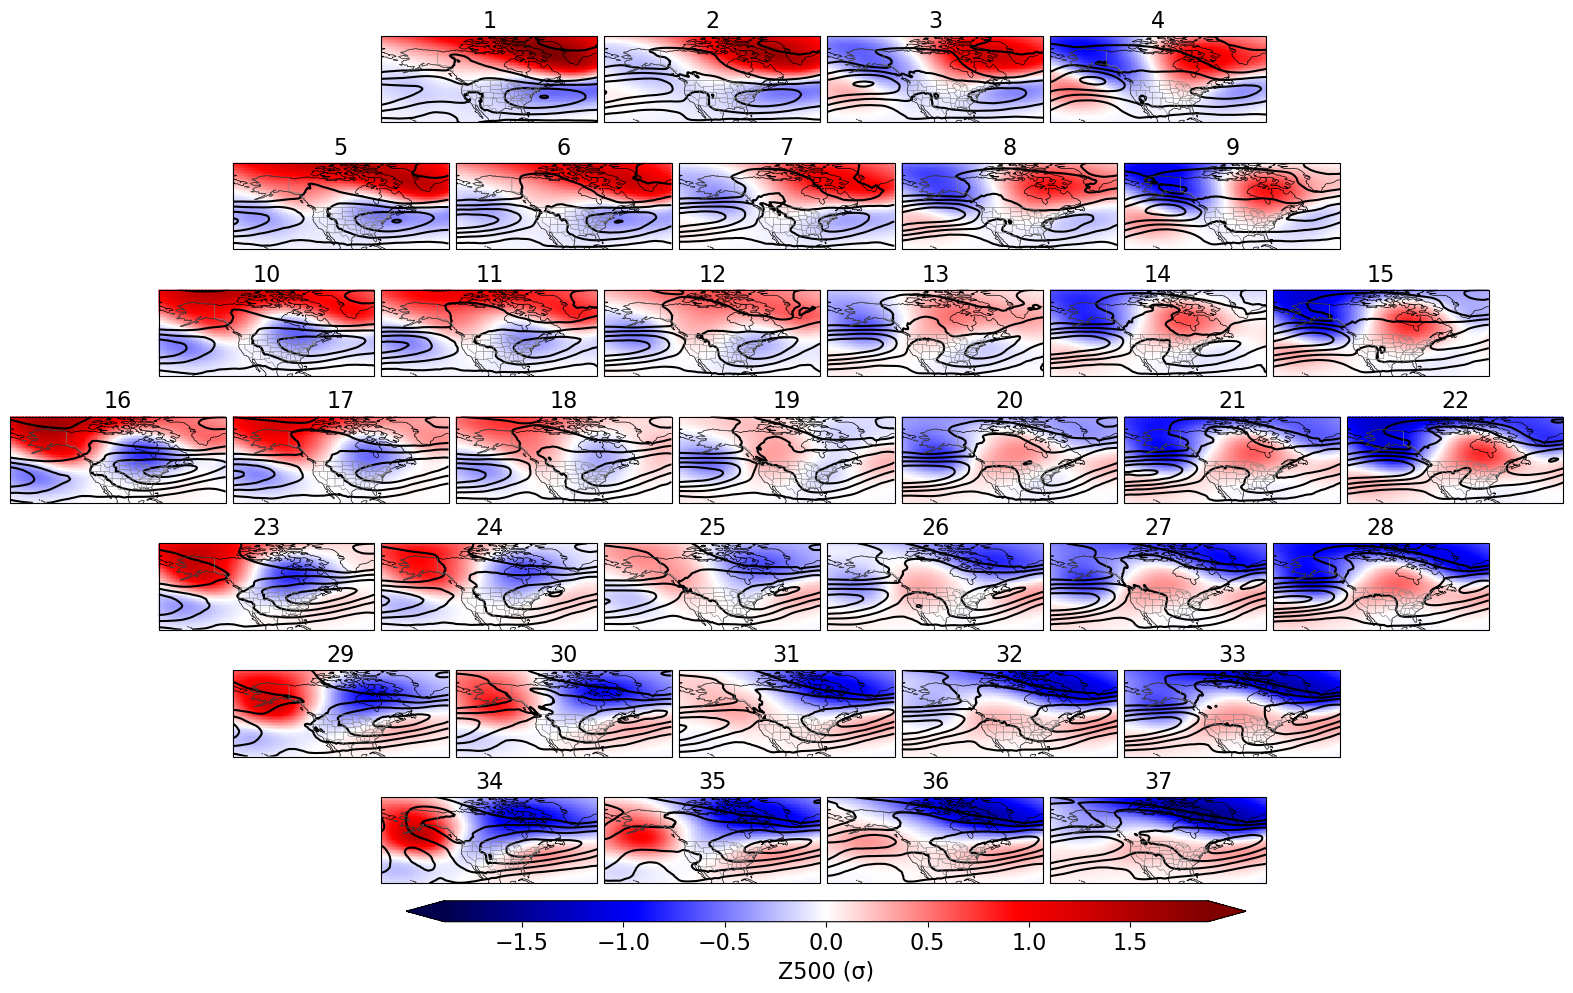

In [68]:
fig, axs = hex_plot(som, projection=ccrs.PlateCarree())

lats = dataset.sel(lat=latSlice, lon=lonSlice).lat
lons = dataset.sel(lat=latSlice, lon=lonSlice).lon - 360
lons, lats = np.meshgrid(lons, lats)

neurons = list(winmap.keys())

for neuron in neurons:
    avgs = np.array(w[neuron[0], neuron[1], :]).reshape((lons.shape[0], lats.shape[1]))
    
    axs[neuron[0], neuron[1]].pcolor(
        lons, lats, avgs, vmin=minimum_weight, vmax=maximum_weight, cmap='seismic', 
        shading='nearest', transform=ccrs.PlateCarree()
    )
    axs[neuron[0], neuron[1]].contour(
        Xcont, Ycont, 
        eu_dict_comp[neuron[0], neuron[1]], 
        levels=[5, 10, 15, 20, 25, 30], colors='k',
        transform=ccrs.PlateCarree()
    )
    
    axs[neuron[0], neuron[1]].set_title(f"{node_nums[neuron]}", fontsize=16)
    
    # background map features
    axs[neuron[0], neuron[1]].coastlines(resolution='110m', color='k', linewidth=0.5, zorder=10)
    axs[neuron[0], neuron[1]].margins(x=0, y=0)
    axs[neuron[0], neuron[1]].add_feature(
        cfeature.STATES, facecolor='none', edgecolor='grey', linewidth=0.25, zorder=10
    )
    axs[neuron[0], neuron[1]].add_feature(
        cf.BORDERS, linewidth=0.25, zorder=10, edgecolor='grey'
    )

cbar_ax = fig.add_axes([0.349, 0.165, 0.4, 0.015])
cmap = mpl.cm.seismic
norm = mpl.colors.Normalize(vmin=minimum_weight, vmax=maximum_weight)
cb = mpl.colorbar.ColorbarBase(ax=cbar_ax, cmap=cmap, norm=norm, orientation='horizontal', extend='both')
cb.ax.tick_params(labelsize=16)
cb.set_label('Z500 (\u03C3)', loc='center', fontsize=16)

plt.subplots_adjust(wspace=-0.475, hspace=-0.75)
plt.savefig('composites.pdf', transparent=True, bbox_inches='tight')
plt.show()

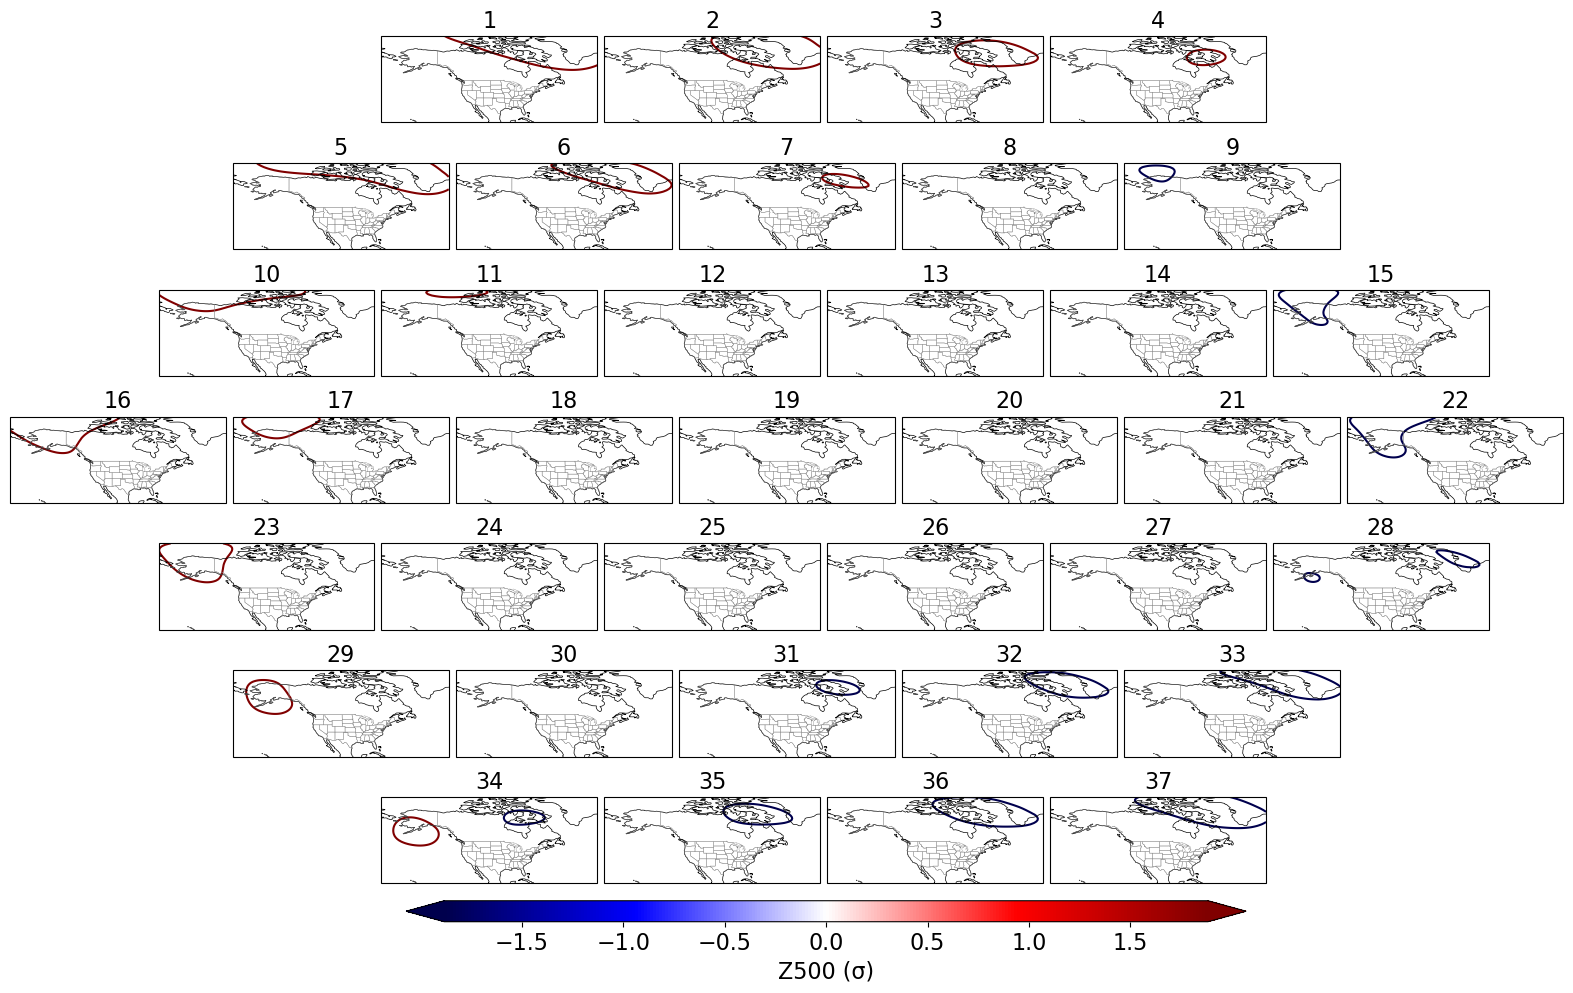

In [72]:
fig, axs = hex_plot(som, projection=ccrs.PlateCarree())

lats = dataset.sel(lat=latSlice, lon=lonSlice).lat
lons = dataset.sel(lat=latSlice, lon=lonSlice).lon - 360
lons, lats = np.meshgrid(lons, lats)

neurons = list(winmap.keys())

for neuron in neurons:
    avgs = np.array(w[neuron[0], neuron[1], :]).reshape((lons.shape[0], lats.shape[1]))
    
    axs[neuron[0], neuron[1]].contour(
        lons, lats, avgs, levels=[-1,1], cmap='seismic', 
        transform=ccrs.PlateCarree()
    )
    
    axs[neuron[0], neuron[1]].set_title(f"{node_nums[neuron]}", fontsize=16)
    
    # background map features
    axs[neuron[0], neuron[1]].coastlines(resolution='110m', color='k', linewidth=0.5, zorder=10)
    axs[neuron[0], neuron[1]].margins(x=0, y=0)
    axs[neuron[0], neuron[1]].add_feature(
        cfeature.STATES, facecolor='none', edgecolor='grey', linewidth=0.25, zorder=10
    )
    axs[neuron[0], neuron[1]].add_feature(
        cf.BORDERS, linewidth=0.25, zorder=10, edgecolor='grey'
    )

cbar_ax = fig.add_axes([0.349, 0.165, 0.4, 0.015])
cmap = mpl.cm.seismic
norm = mpl.colors.Normalize(vmin=minimum_weight, vmax=maximum_weight)
cb = mpl.colorbar.ColorbarBase(ax=cbar_ax, cmap=cmap, norm=norm, orientation='horizontal', extend='both')
cb.ax.tick_params(labelsize=16)
cb.set_label('Z500 (\u03C3)', loc='center', fontsize=16)

plt.subplots_adjust(wspace=-0.475, hspace=-0.75)
#plt.savefig('composites.pdf', transparent=True, bbox_inches='tight')
plt.show()